In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
np.random.seed(42)
torch.manual_seed(42)

In [3]:
n_days = 200

dates = pd.date_range(start="2024-01-01", periods=n_days, freq="D")
t = np.arange(n_days)

trend = 50 + 0.15 * t
seasonality = 8 * np.sin(2 * np.pi * t / 7)
noise = np.random.normal(loc=0, scale=3, size=n_days)

sales = trend + seasonality + noise

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df.head()

,date,sales
0,2024-01-01,51.490142
1,2024-01-02,55.989859
2,2024-01-03,60.042489
3,2024-01-04,58.490159
4,2024-01-05,46.426470


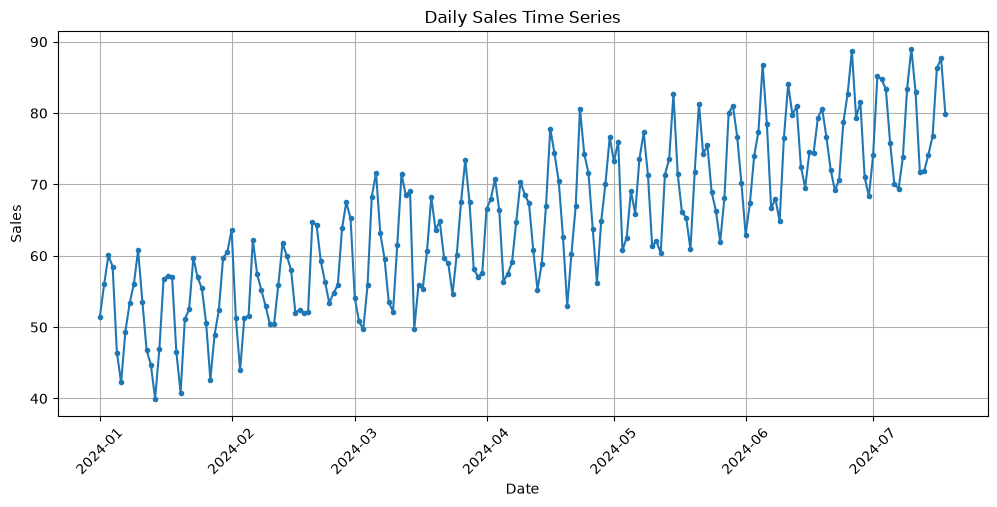

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"], marker="o", markersize=3)
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [5]:
def create_sliding_windows(series, window_size=7, horizon=1):
    """
    把一条时间序列切成滑动窗口样本。

    series: 一维时间序列
    window_size: 输入窗口长度
    horizon: 预测未来第几个时间点

    返回：
    X: [样本数, window_size]
    y: [样本数]
    """
    X = []
    y = []

    for i in range(len(series) - window_size - horizon + 1):
        X_window = series[i : i + window_size]
        y_target = series[i + window_size + horizon - 1]

        X.append(X_window)
        y.append(y_target)

    return np.array(X), np.array(y)

In [6]:
series = df["sales"].values
date_values = df["date"].values

train_ratio = 0.8
train_size = int(len(series) * train_ratio)

train_series_raw = series[:train_size]
test_series_raw = series[train_size:]

train_dates = date_values[:train_size]
test_dates = date_values[train_size:]

print("训练集长度:", len(train_series_raw))
print("测试集长度:", len(test_series_raw))

print("训练集时间范围:", train_dates[0], "到", train_dates[-1])
print("测试集时间范围:", test_dates[0], "到", test_dates[-1])

训练集长度: 160
测试集长度: 40
训练集时间范围: 2024-01-01T00:00:00.000000 到 2024-06-08T00:00:00.000000
测试集时间范围: 2024-06-09T00:00:00.000000 到 2024-07-18T00:00:00.000000


In [7]:
train_mean = train_series_raw.mean()
train_std = train_series_raw.std()

train_series = (train_series_raw - train_mean) / train_std
test_series = (test_series_raw - train_mean) / train_std

print("训练集均值:", train_mean)
print("训练集标准差:", train_std)

训练集均值: 61.761286297147876
训练集标准差: 9.434552516939089


In [8]:
window_size = 7
horizon = 1

X_train, y_train = create_sliding_windows(
    train_series,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_series,
    window_size=window_size,
    horizon=horizon
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (153, 7)
y_train shape: (153,)
X_test shape: (33, 7)
y_test shape: (33,)


In [9]:
sample_idx = 0

print("输入 X:")
print(X_train[sample_idx])

print("预测目标 y:")
print(y_train[sample_idx])

输入 X:
[-1.08867313 -0.61173302 -0.18218112 -0.34671775 -1.62538884 -2.06826136
 -1.31201768]
预测目标 y:
-0.8912963380712978


In [10]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
batch_size = 16

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

for batch_X, batch_y in train_loader:
    print("batch_X shape:", batch_X.shape)
    print("batch_y shape:", batch_y.shape)
    break

batch_X shape: torch.Size([16, 7])
batch_y shape: torch.Size([16, 1])


In [12]:
class MLPForecaster(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
input_dim = window_size

model = MLPForecaster(input_dim=input_dim)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

MLPForecaster(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [14]:
num_epochs = 200

train_losses = []

for epoch in range(num_epochs):
    model.train()

    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        # 前向传播
        preds = model(batch_X)

        # 计算损失
        loss = criterion(preds, batch_y)

        # 清空梯度
        optimizer.zero_grad()

        # 反向传播
        loss.backward()

        # 更新参数
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss = epoch_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Epoch [20/200], Loss: 0.110494
Epoch [40/200], Loss: 0.093306
Epoch [60/200], Loss: 0.084185
Epoch [80/200], Loss: 0.067511
Epoch [100/200], Loss: 0.061810
Epoch [120/200], Loss: 0.051063
Epoch [140/200], Loss: 0.046179
Epoch [160/200], Loss: 0.039160
Epoch [180/200], Loss: 0.034213
Epoch [200/200], Loss: 0.027402


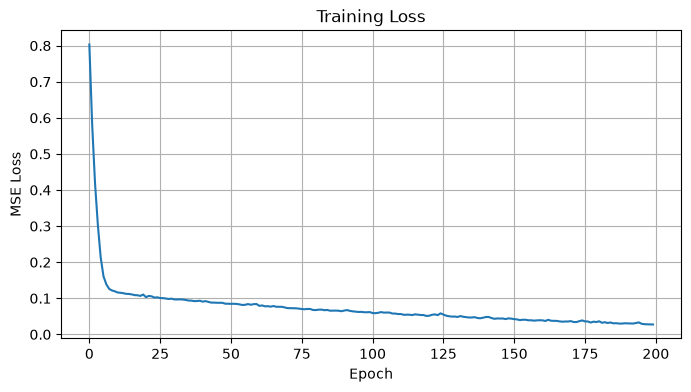

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [16]:
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)

        test_preds.append(preds.numpy())
        test_targets.append(batch_y.numpy())

test_preds = np.concatenate(test_preds).reshape(-1)
test_targets = np.concatenate(test_targets).reshape(-1)

print("test_preds shape:", test_preds.shape)
print("test_targets shape:", test_targets.shape)

test_preds shape: (33,)
test_targets shape: (33,)


In [17]:
test_preds_raw = test_preds * train_std + train_mean
test_targets_raw = test_targets * train_std + train_mean

print("前 5 个真实值:", test_targets_raw[:5])
print("前 5 个预测值:", test_preds_raw[:5])

前 5 个真实值: [74.48572732 74.46383531 79.34344316 80.63087944 76.6736392 ]
前 5 个预测值: [68.00810162 76.95323734 82.20799331 87.76537874 80.77039678]


In [18]:
mae = np.mean(np.abs(test_targets_raw - test_preds_raw))
rmse = np.sqrt(np.mean((test_targets_raw - test_preds_raw) ** 2))

print("MLP Test MAE:", mae)
print("MLP Test RMSE:", rmse)

MLP Test MAE: 3.489386457099165
MLP Test RMSE: 4.184969828367897


In [19]:
# y_test 对应的是 test_series_raw 从 window_size 之后的点
test_target_dates = test_dates[window_size:]

# naive 预测：用前一天的真实值预测今天
naive_preds_raw = test_series_raw[window_size - 1 : -1]
naive_targets_raw = test_series_raw[window_size:]

print("naive_preds_raw shape:", naive_preds_raw.shape)
print("naive_targets_raw shape:", naive_targets_raw.shape)

naive_preds_raw shape: (33,)
naive_targets_raw shape: (33,)


In [20]:
naive_mae = np.mean(np.abs(naive_targets_raw - naive_preds_raw))
naive_rmse = np.sqrt(np.mean((naive_targets_raw - naive_preds_raw) ** 2))

print("Naive Baseline MAE:", naive_mae)
print("Naive Baseline RMSE:", naive_rmse)

Naive Baseline MAE: 4.848231906064176
Naive Baseline RMSE: 5.881542808220443


In [21]:
result_df = pd.DataFrame({
    "model": ["Naive Baseline", "MLP"],
    "MAE": [naive_mae, mae],
    "RMSE": [naive_rmse, rmse]
})

result_df

,model,MAE,RMSE
0,Naive Baseline,4.848232,5.881543
1,MLP,3.489386,4.184970


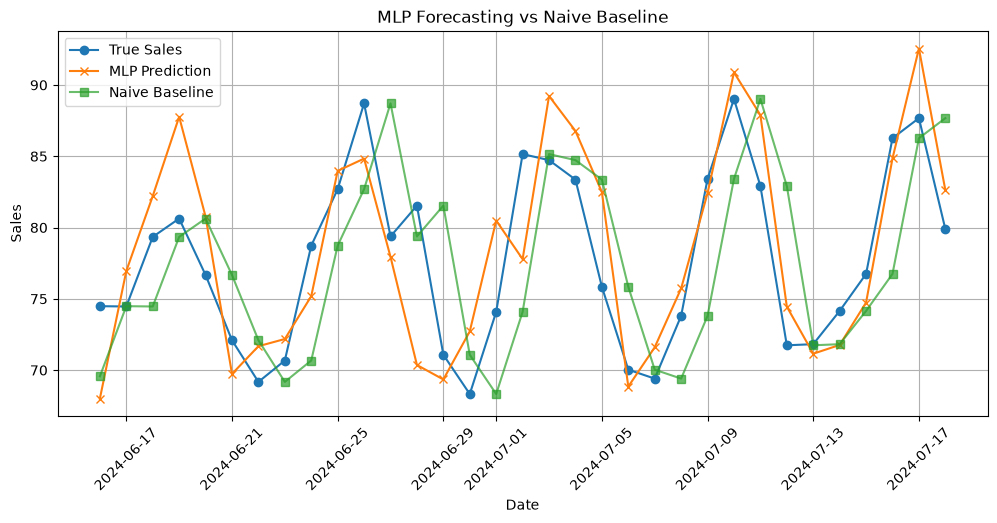

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(test_target_dates, test_targets_raw, marker="o", label="True Sales")
plt.plot(test_target_dates, test_preds_raw, marker="x", label="MLP Prediction")
plt.plot(test_target_dates, naive_preds_raw, marker="s", label="Naive Baseline", alpha=0.7)

plt.title("MLP Forecasting vs Naive Baseline")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

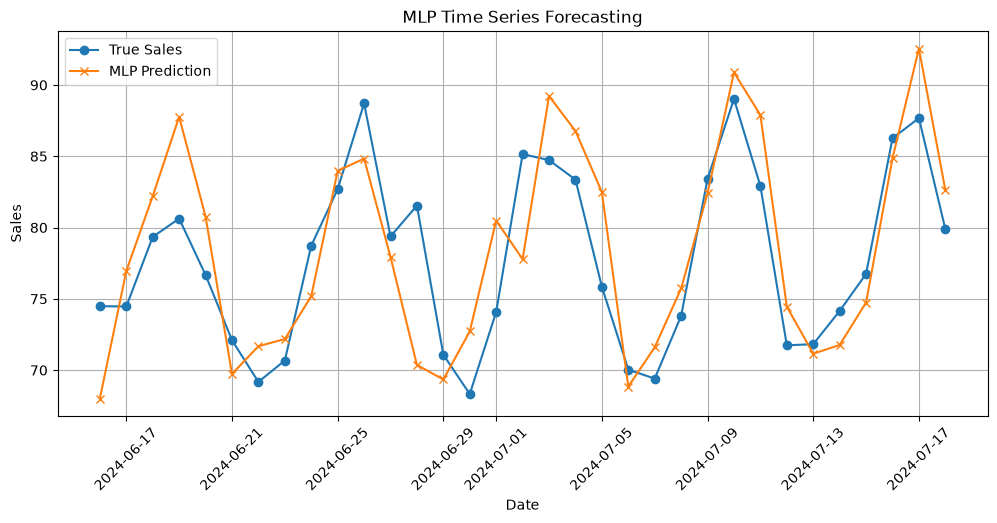

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(test_target_dates, test_targets_raw, marker="o", label="True Sales")
plt.plot(test_target_dates, test_preds_raw, marker="x", label="MLP Prediction")

plt.title("MLP Time Series Forecasting")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [24]:
prediction_df = pd.DataFrame({
    "date": test_target_dates,
    "true_sales": test_targets_raw,
    "mlp_pred": test_preds_raw,
    "naive_pred": naive_preds_raw
})

prediction_df.head(10)

,date,true_sales,mlp_pred,naive_pred
0,2024-06-16,74.485727,68.008102,69.566757
1,2024-06-17,74.463835,76.953237,74.485727
2,2024-06-18,79.343443,82.207993,74.463836
3,2024-06-19,80.630879,87.765379,79.343443
4,2024-06-20,76.673639,80.770397,80.630880
5,2024-06-21,72.097625,69.731325,76.673639
6,2024-06-22,69.174032,71.676938,72.097625
7,2024-06-23,70.675421,72.182849,69.174033
8,2024-06-24,78.731550,75.186780,70.675421
9,2024-06-25,82.693658,83.974169,78.731550


In [25]:
prediction_df["mlp_error"] = prediction_df["true_sales"] - prediction_df["mlp_pred"]
prediction_df["naive_error"] = prediction_df["true_sales"] - prediction_df["naive_pred"]

prediction_df.head()

,date,true_sales,mlp_pred,naive_pred,mlp_error,naive_error
0,2024-06-16,74.485727,68.008102,69.566757,6.477626,4.918970
1,2024-06-17,74.463835,76.953237,74.485727,-2.489402,-0.021892
2,2024-06-18,79.343443,82.207993,74.463836,-2.864550,4.879608
3,2024-06-19,80.630879,87.765379,79.343443,-7.134499,1.287436
4,2024-06-20,76.673639,80.770397,80.630880,-4.096758,-3.957241


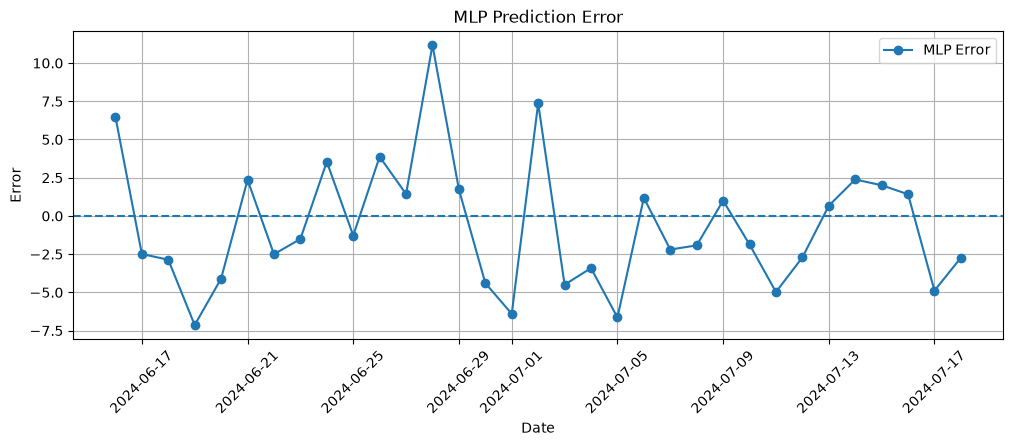

In [26]:
plt.figure(figsize=(12, 4))

plt.plot(prediction_df["date"], prediction_df["mlp_error"], marker="o", label="MLP Error")
plt.axhline(0, linestyle="--")

plt.title("MLP Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [27]:
def train_mlp_with_window_size(window_size, num_epochs=100):
    X_train, y_train = create_sliding_windows(train_series, window_size=window_size, horizon=1)
    X_test, y_test = create_sliding_windows(test_series, window_size=window_size, horizon=1)

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    model = MLPForecaster(input_dim=window_size)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        model.train()

        for batch_X, batch_y in train_loader:
            preds = model(batch_X)
            loss = criterion(preds, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()

    preds_list = []
    targets_list = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X)
            preds_list.append(preds.numpy())
            targets_list.append(batch_y.numpy())

    preds = np.concatenate(preds_list).reshape(-1)
    targets = np.concatenate(targets_list).reshape(-1)

    preds_raw = preds * train_std + train_mean
    targets_raw = targets * train_std + train_mean

    mae = np.mean(np.abs(targets_raw - preds_raw))
    rmse = np.sqrt(np.mean((targets_raw - preds_raw) ** 2))

    return mae, rmse

In [28]:
window_results = []

for ws in [3, 7, 14, 21]:
    mae_ws, rmse_ws = train_mlp_with_window_size(window_size=ws, num_epochs=100)

    window_results.append({
        "window_size": ws,
        "MAE": mae_ws,
        "RMSE": rmse_ws
    })

window_result_df = pd.DataFrame(window_results)
window_result_df

,window_size,MAE,RMSE
0,3,7.377391,8.347853
1,7,2.507421,3.304872
2,14,2.850599,3.951205
3,21,4.091733,4.594575


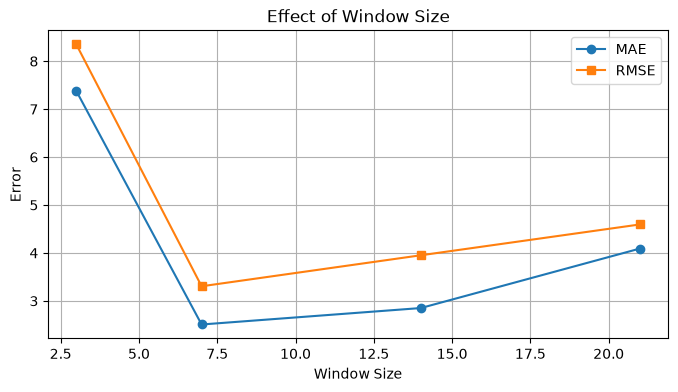

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(window_result_df["window_size"], window_result_df["MAE"], marker="o", label="MAE")
plt.plot(window_result_df["window_size"], window_result_df["RMSE"], marker="s", label="RMSE")

plt.title("Effect of Window Size")
plt.xlabel("Window Size")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()